In [6]:
# =====================================================================
# INITIAL SETUP & ENVIRONMENT DEPENDENCIES
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# AAPKA EXACT LOCAL DIRECTORY PATH
DATASET_DIR = "C:/Users/Lenovo/Downloads/ai_project_synthetic_datasets-20260514T180014Z-3-001/ai_project_synthetic_datasets/part_2_cnn_computer_vision"  
CSV_PATH = os.path.join(DATASET_DIR, "labels.csv")

# Hyperparameters setup
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

# Expected Repository directory structure automatically create karna
os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

print("Environment Setup Successfully Completed!")
print("Checking Path Access for labels.csv:", os.path.exists(CSV_PATH))
print("TensorFlow Version running:", tf.__version__)

Environment Setup Successfully Completed!
Checking Path Access for labels.csv: True
TensorFlow Version running: 2.21.0


In [8]:
# =====================================================================
# TASK 2: DATASET EXPLORATION
# =====================================================================
# CSV load karna aur paths fix karna
df = pd.read_csv(CSV_PATH)
df['filename'] = df['filename'].apply(lambda x: os.path.abspath(os.path.join(DATASET_DIR, x.strip())))

print("--- [TASK 2] EXTRACTED DATASET METRICS ---")
print(f"Total Images present in folder: {len(df)}")
print("\nImages distribution per class:")
class_distribution = df['class'].value_counts()
print(class_distribution)

# Checking Imbalance
max_samples = class_distribution.max()
min_samples = class_distribution.min()
imbalance_ratio = max_samples / min_samples
print(f"\nCalculated Imbalance Ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print("Dataset Assessment: Imbalance detected.")
else:
    print("Dataset Assessment: Classes are balanced smoothly (Minor difference is acceptable).")

--- [TASK 2] EXTRACTED DATASET METRICS ---
Total Images present in folder: 480

Images distribution per class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Calculated Imbalance Ratio: 1.00
Dataset Assessment: Classes are balanced smoothly (Minor difference is acceptable).


Found 308 validated image filenames belonging to 4 classes.
Found 76 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.


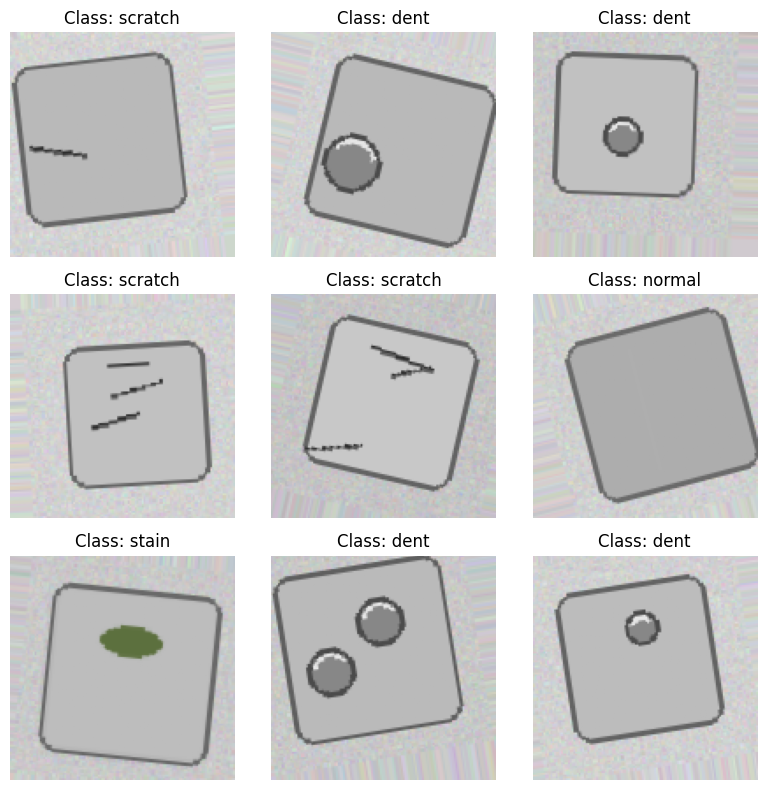

In [9]:
# =====================================================================
# TASK 3: IMAGE PREPROCESSING (SPLITTING, NORMALIZATION, RESIZING & AUGMENTATION)
# =====================================================================
# 1. Splitting: Training Set (80%) and Test Set (20%)
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['class'])

# 2. Normalization & Augmentation configurations
train_datagen = ImageDataGenerator(
    rescale=1./255,          # <-- NORMALIZATION [0, 255] to [0.0, 1.0]
    rotation_range=15,       # <-- AUGMENTATION (Random rotations)
    width_shift_range=0.1,   # <-- AUGMENTATION (Horizontal Shifts)
    height_shift_range=0.1,  # <-- AUGMENTATION (Vertical Shifts)
    horizontal_flip=True,    # <-- ... [AUGMENTATION]
    validation_split=0.2     # Dynamic Validation subset isolation
)

test_datagen = ImageDataGenerator(rescale=1./255) # Testing data only gets normalization

# 3. Resizing configuration dynamically inside image streams
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE,    # <-- FIXED RESIZING TO 128x128
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=42
)

val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE,    # <-- FIXED RESIZING TO 128x128
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE,    # <-- FIXED RESIZING TO 128x128
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

# Visualization of samples after preprocessing pipeline activation
images, labels = next(train_generator)
plt.figure(figsize=(8, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {class_names[np.argmax(labels[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# =====================================================================
# TASK 4: CNN MODEL CREATION (WARNING-FREE UPDATED VERSION)
# =====================================================================
model = models.Sequential([
    # Naye TensorFlow/Keras standard ke mutabik Input Layer alag se lagayi gayi hai
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Layer 1: Convolution Layer + ReLU Activation + Pooling Layer
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 2: Deep Feature Extraction Layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 3: High-level Pattern Map Layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten Layer: Converting multidimensional grids into 1D array vector
    layers.Flatten(),
    
    # Dense Layer (Fully Connected Processing Units)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Drops 50% nodes to stop memorization overfitting
    
    # Output Layer utilizing Softmax function for categorical outputs
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Printing summary model parameters layout
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =====================================================================
# TASK 5: MODEL TRAINING
# =====================================================================
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 752ms/step - accuracy: 0.2565 - loss: 1.5845 - val_accuracy: 0.2105 - val_loss: 1.3934
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 383ms/step - accuracy: 0.2305 - loss: 1.3949 - val_accuracy: 0.2105 - val_loss: 1.3918
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 396ms/step - accuracy: 0.2370 - loss: 1.3862 - val_accuracy: 0.2105 - val_loss: 1.3860
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 390ms/step - accuracy: 0.2792 - loss: 1.3852 - val_accuracy: 0.2105 - val_loss: 1.3963
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 375ms/step - accuracy: 0.2532 - loss: 1.3894 - val_accuracy: 0.2105 - val_loss: 1.3853
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 385ms/step - accuracy: 0.2695 - loss: 1.3837 - val_accuracy: 0.2105 - val_loss: 1.3881
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 407ms/step - accuracy: 0.2987 - loss: 1.3704 - val_accuracy: 0.2763 - val_loss: 1.3679
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 388ms/step - accuracy: 0.3442 - loss: 1.3065 - val_accuracy: 0.

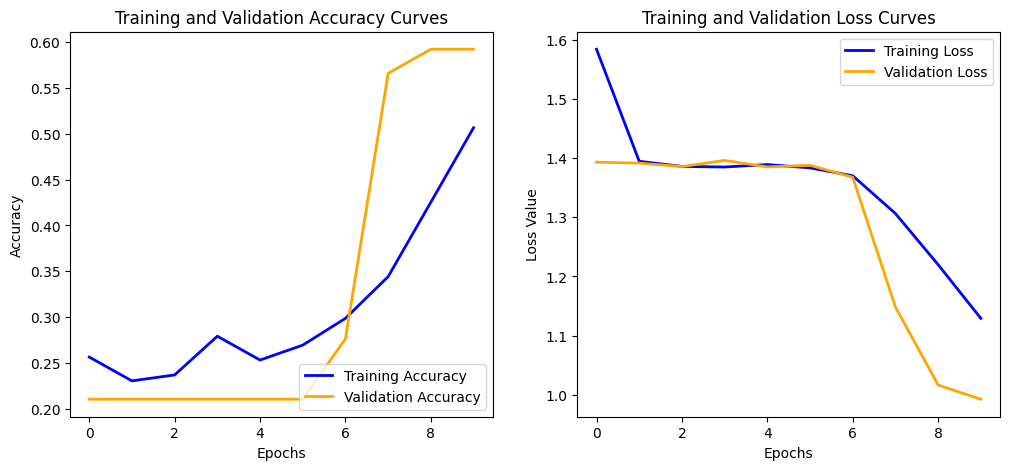

Artifact Created Successfully: results/accuracy_loss_curves.png saved.


In [19]:
# =====================================================================
# SAVE LOSS & ACCURACY PROFILES
# =====================================================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Profile 1: Accuracy Curve Mapping
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', lw=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Profile 2: Cross Entropy Loss Mapping
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', lw=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')

# Artifact Save inside results directory
plt.savefig('results/accuracy_loss_curves.png', bbox_inches='tight')
plt.show()
print("Artifact Created Successfully: results/accuracy_loss_curves.png saved.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.6458 - loss: 0.8664

--- Final Isolation Test Output Metrics ---
Test Accuracy: 64.58%
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


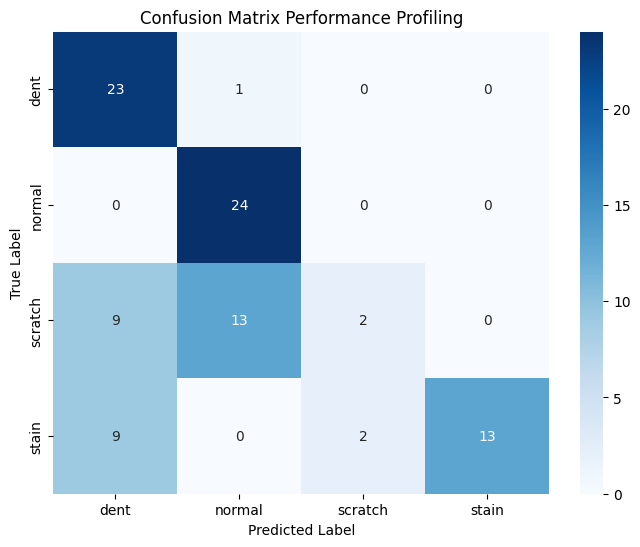

Artifact Created Successfully: results/confusion_matrix.png saved.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


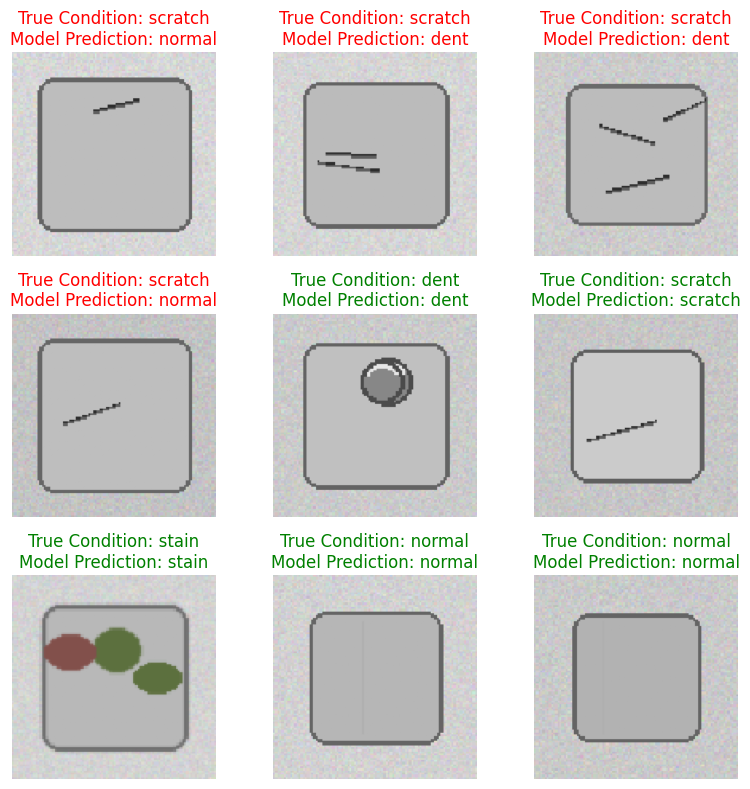

Artifact Created Successfully: sample_predictions/prediction_outputs.png saved.


In [21]:
# =====================================================================
# CONFUSION MATRIX & INFERENCE VISUALS
# =====================================================================
# Isolated test partition matrix calculation
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n--- Final Isolation Test Output Metrics ---")
print(f"Test Accuracy: {test_acc*100:.2f}%")

test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Generate Heatmap Matrix for Evaluation
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Performance Profiling')

# Artifact Save inside results directory
plt.savefig('results/confusion_matrix.png', bbox_inches='tight')
plt.show()
print("Artifact Created Successfully: results/confusion_matrix.png saved.")

# =====================================================================
# ARTIFACT GENERATION - EXPORT PREDICTION OUTPUTS IMAGE
# =====================================================================
test_generator.reset()
images, labels = next(test_generator)
preds = model.predict(images)

plt.figure(figsize=(8, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    
    true_lbl = class_names[np.argmax(labels[i])]
    pred_lbl = class_names[np.argmax(preds[i])]
    
    color_marker = 'green' if true_lbl == pred_lbl else 'red'
    plt.title(f"True Condition: {true_lbl}\nModel Prediction: {pred_lbl}", color=color_marker)
    plt.axis('off')

plt.tight_layout()
# Artifact Save inside sample_predictions directory
plt.savefig('sample_predictions/prediction_outputs.png', bbox_inches='tight')
plt.show()
print("Artifact Created Successfully: sample_predictions/prediction_outputs.png saved.")